# Lab 6: Graphical Models

Welcome to the advanced Machine Learning Course.

The objective of this lab session is to code a few regression algorithms and to apply them to synthetic and real datasets.

Please put **"ML - MDS - TD6"** in the mail subject or I might lose your work (which means 0) and send it to pierre.houdouin@centralesupelec.fr

Please label your notebook **"L6_familyname1_familyname2.ipynb"** or I might lose your work (which means 0).

We begin with the standard imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}
from tqdm import tqdm
import networkx as nx
import scipy
import warnings
warnings.filterwarnings("ignore")

In [2]:
class my_GLasso():
    
    def __init__(self, lambd=0.01, nu=0.01, max_iter = 60):
        '''
        Parameters:
        alpha : float
            Penalization parameter selected.
        mu: float>0

        Attributes:
        
        covariance_ : numpy.ndarray, shape (n_features, n_features)
            Estimated covariance matrix.
        precision_ : numpy.ndarray, shape (n_features, n_features)
            Estimated precision matrix (inverse covariance).
        '''
        self.covariance_ = None
        self.precision_ = None
        self.lambd = lambd
        self.nu = nu
        self.max_iter = max_iter
        
    def fit(self, X):
        """ Fits the GraphicalLasso model to X.
        
        Parameters:
        -----------
        X: (n, p) np.array
            Data matrix
        
        Returns:
        -----
        self
        """         
        n, p = X.shape
        X_mean = X.mean(axis=0)
        S = np.cov(X - X_mean, rowvar=False)
        self.covariance_ = S
        
        # Initialize
        P = np.eye(p)    # precision matrix
        Z = np.eye(p)    # auxiliary variable
        U = np.zeros((p, p))  # dual variable

        for _ in range(self.max_iter):
            # Solve: -logdet(P) + trace(SP) + (nu/2)*||P - Z + U||^2
            Q = Z - U
            eigvals, eigvecs = np.linalg.eigh(self.nu * Q - S)
            d = (eigvals + np.sqrt(eigvals**2 + 4 * self.nu)) / (2 * self.nu)
            P = eigvecs @ np.diag(d) @ eigvecs.T
            
            # Update Z with soft-thresholding
            X_temp = P + U
            Z = np.sign(X_temp) * np.maximum(np.abs(X_temp) - self.lambd / self.nu, 0)
            np.fill_diagonal(Z, np.diag(X_temp))  
            
            # Update dual variable
            U = U + P - Z
  
        self.precision_ = P
        return P

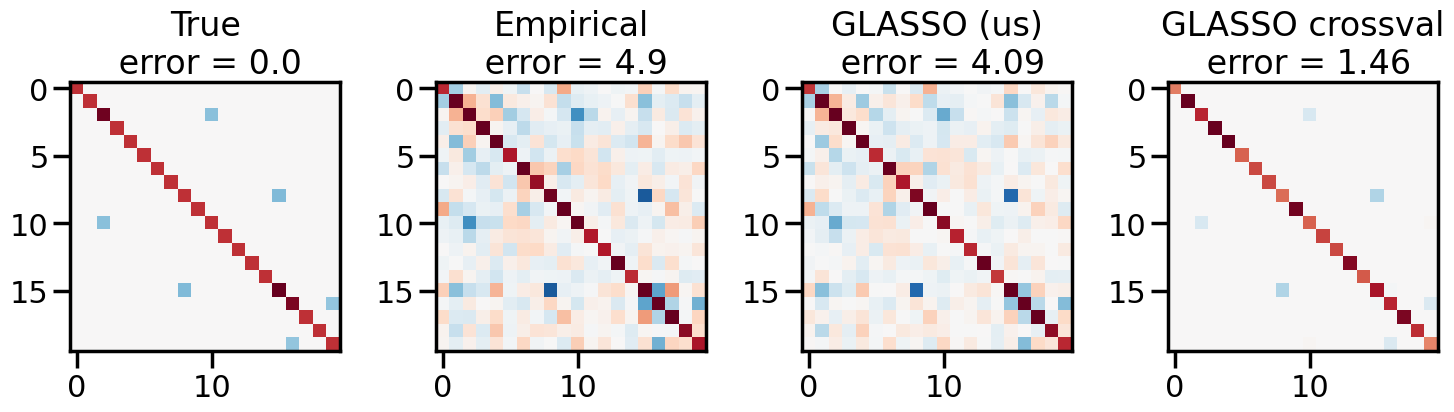

In [3]:
# TODO : Compare methods of estimating the covariance matrix in low-sample regime
n_samples = 60
n_features = 20

# Simulate data (multivariate gaussian)
from sklearn.datasets import make_sparse_spd_matrix
rng = np.random.RandomState(1)
prec = make_sparse_spd_matrix(n_features, alpha=.98, smallest_coef=.4, largest_coef=.7, random_state=rng)
cov = np.linalg.inv(prec)
mean = np.zeros(n_features)
data = np.random.multivariate_normal(mean, cov, n_samples)
err = np.linalg.norm(prec - prec)

prec_empirical = np.linalg.inv(np.dot(data.T, data) / n_samples)
err_empirical = np.linalg.norm(prec - prec_empirical)

# Scikit-learn Graphical Lasso with cross validation 
from sklearn.covariance import GraphicalLassoCV
model = GraphicalLassoCV()
model.fit(data)
prec_glassocv = model.precision_
err_glassocv = np.linalg.norm(prec - prec_glassocv)

# Graphical Lasso estimation using our implementation

mymodel = my_GLasso()
mymodel.fit(data)
prec_glasso = mymodel.precision_
err_glasso = np.linalg.norm(prec - prec_glasso)

# Visual comparison

titles = ["True", "Empirical", "GLASSO (us)", "GLASSO crossval"]
imgs = [prec, prec_empirical, prec_glasso, prec_glassocv]
errors = [err, err_empirical, err_glasso, err_glassocv]

vmax = np.max(np.abs(prec))
ncols = len(titles)
fig, axes = plt.subplots(1, ncols, figsize=(15, 5))
for idx, ax in enumerate(axes.flatten()):
    img = imgs[idx]
    error = np.around(errors[idx], decimals=2)
    title = titles[idx] + f'\n error = {error}'
    ax.imshow(img, vmin=-vmax, vmax=vmax, interpolation='nearest', cmap=plt.cm.RdBu_r)
    ax.set_title(title)
fig.tight_layout()

### Nodewise Regression

Fill in the following class that implements the nodewise regression algorithm to estimate a graphical model structure. You can use `LassoCV` for the regressions. Bonus (not graded): Implement your own cross-validation lasso.

In [4]:
from sklearn.linear_model import LassoCV

class my_nodewise_regression():
    
    def __init__(self, rule='AND', eps=1e-8):
        '''
        Parameters:
        
        rule: {"OR", "AND"}
        
        Attributes:
        
        graph_structure_ : numpy.ndarray, shape (n_features, n_features)
            Estimated adjacancy matrix.        
        '''
        self.graph_structure_ = None
        self.rule = rule
        self.eps = eps
        
    def fit(self, X):
        """ Fit the model to X.
        
        Parameters:
        -----------
        X: (n, p) np.array
            Data matrix
        
        Returns:
        -----
        self
        """         
        #TODO
        n, p = X.shape
        betas = np.zeros((p, p))
        S = [set() for _ in range(p)]
        
        for i in range(p):
            mask = np.arange(p) != i
            X_minus_i = X[:, mask]
            coef = LassoCV(eps=self.eps, max_iter=100).fit(X_minus_i, X[:, i]).coef_
            betas[i, :i] = coef[:i]
            betas[i, i+1:] = coef[i:]
            S[i] = set(np.where(betas[i] != 0)[0])
        
        if self.rule == "AND":
            self.graph_structure_ = (betas != 0) & (betas.T != 0)
        elif self.rule == "OR":
            self.graph_structure_ = (betas != 0) | (betas.T != 0)
        else:
            raise ValueError("rule must be 'AND' or 'OR'")
        
        return self.graph_structure_       

In [5]:
np.random.seed(1)
n = 5000
p = 6
epsilon=1e-1
X = np.random.randn(n, p)
X.T[1] += X.T[0]
X.T[2] += X.T[1]
real_graph_structure = np.zeros((p, p))
real_graph_structure[0,1] = 1
real_graph_structure[1,0] = 1
real_graph_structure[1,2] = 1
real_graph_structure[2,1] = 1

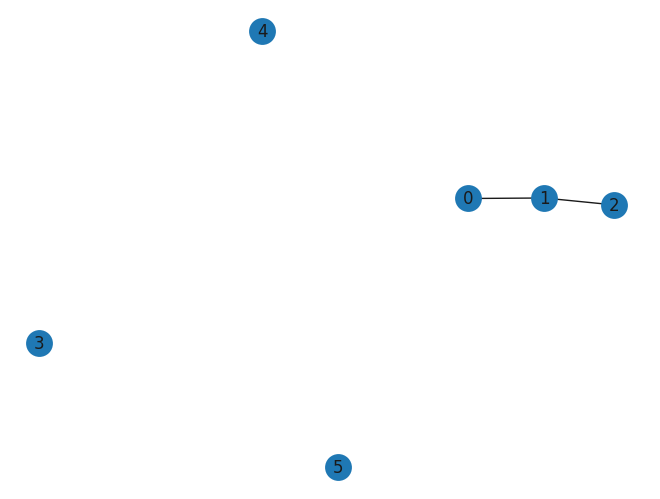

In [6]:
nx_real = nx.from_numpy_array(real_graph_structure.T)
nx.draw(nx_real, with_labels=True)

#On dessine la structure initiale

We notice that the initial graph is **poorly connected**, there are a lot of conditional independances between the components.

When we will reconstruct the graph with the predicted value of the precision matrix, **we expect higher values for the conditional correlation between nodes 0, 1 and 2**. 

However, based on what we saw before, we must expect a complete graph if we dont specify a minimum weight for the edges to be taken into account.

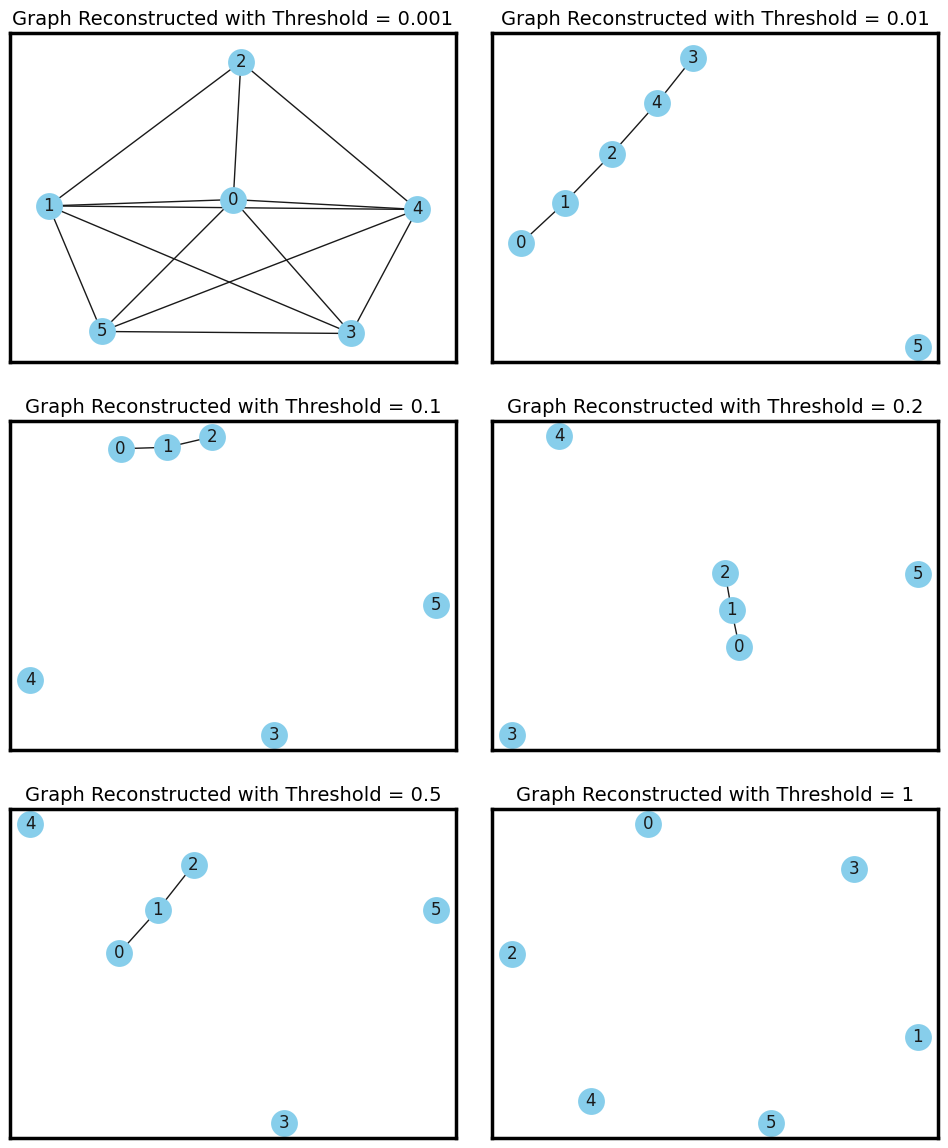

In [8]:
#TODO : plot the reconstructed graph with GLASSO using different thresholds. Comment the impact of the choice of the threshold
eps_list = [1e-3, 1e-2, 1e-1, 2e-1, 5e-1, 1]
fig, axes = plt.subplots(len(eps_list)//2, 2, figsize=(10, 12))
axes = axes.flatten()
for i, eps in enumerate(eps_list):
    model = my_GLasso()
    model.fit(X)
    P = model.precision_
    np.fill_diagonal(P, 0)
    nx_P = nx.from_numpy_array((np.abs(P) > eps).astype(int).T)
    nx.draw(nx_P, with_labels=True, node_color='skyblue', ax=axes[i])
    axes[i].set_title(f"Graph Reconstructed with Threshold = {eps}", fontsize=14)
    axes[i].axis('on')  

plt.tight_layout()
plt.show()

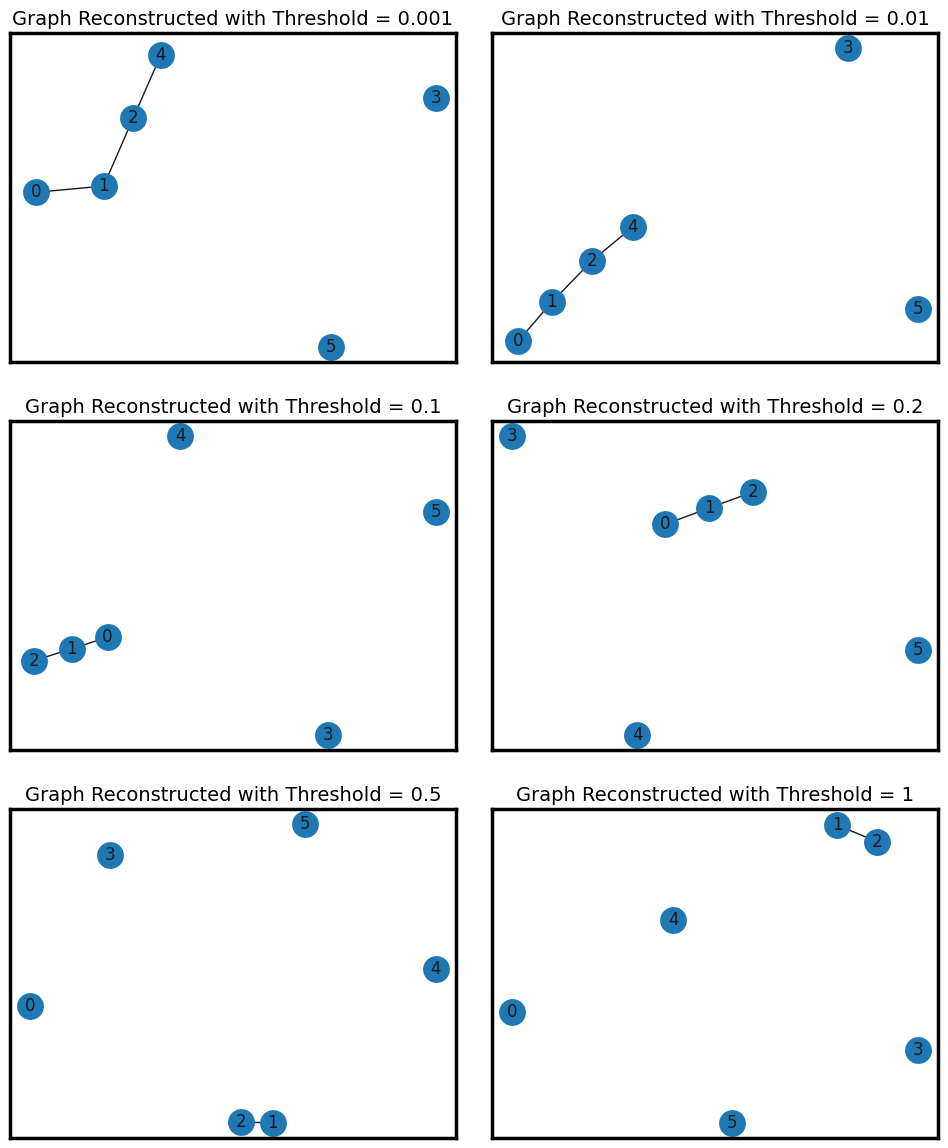

In [9]:
#TODO : plot the reconstructed graph with nodewise regression using the rule OR
eps_list = [1e-3, 1e-2, 1e-1, 2e-1, 5e-1, 1]
fig, axes = plt.subplots(len(eps_list)//2, 2, figsize=(10, 12))
axes = axes.flatten()
for i,eps in enumerate(eps_list):
    model_AND = my_nodewise_regression(eps=eps, rule="AND")
    graph_structure_AND = model_AND.fit(X)
    nx_graph = nx.from_numpy_array(graph_structure_AND.T)
    nx.draw(nx_graph, with_labels=True, ax=axes[i])
    axes[i].set_title(f"Graph Reconstructed with Threshold = {eps}", fontsize=14)
    axes[i].axis('on')  

plt.tight_layout()
plt.show()

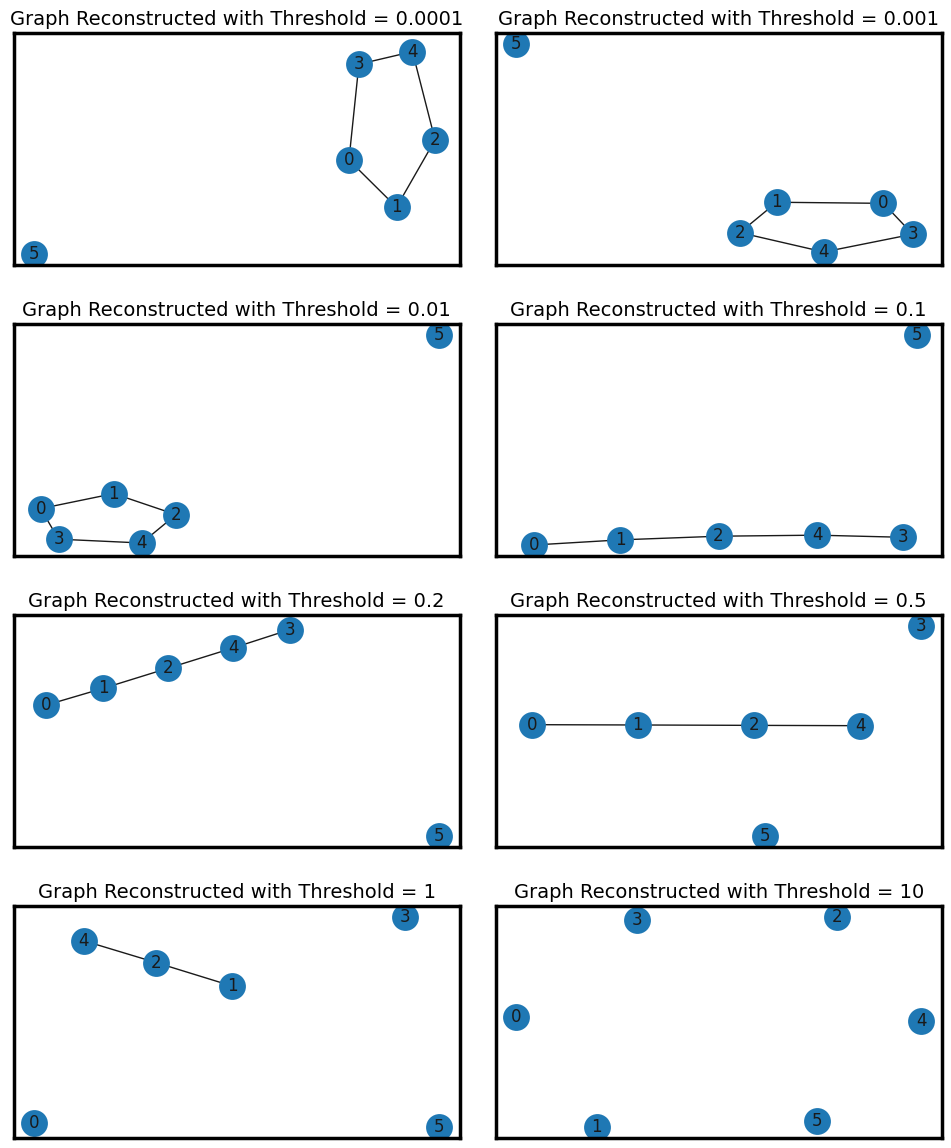

In [42]:
#TODO : plot the reconstructed graph with nodewise regression using the rule OR
eps_list = [1e-4, 1e-3, 1e-2, 1e-1, 2e-1, 5e-1, 1, 10]
fig, axes = plt.subplots(len(eps_list)//2, 2, figsize=(10, 12))
axes = axes.flatten()
for i,eps in enumerate(eps_list):
    model_OR = my_nodewise_regression(eps=eps, rule="OR")
    graph_structure_OR = model_OR.fit(X)
    nx_graph = nx.from_numpy_array(graph_structure_OR.T)
    nx.draw(nx_graph, with_labels=True, ax=axes[i])
    axes[i].set_title(f"Graph Reconstructed with Threshold = {eps}", fontsize=14)
    axes[i].axis('on')  

plt.tight_layout()
plt.show()

## Simulations

Compare the two graph estimators for each of the following models with $p = 300$ and $n = 40, 80, 320$:

- An AR(1)-Block model. In this model the *covariance* matrix is block-diagonal with equalsized AR(1)-blocks of the form $(\Sigma_{Block})_{i, j} = 0.9^{|i−j|}$, take $30 \times 30$ blocks.
- The exponential decay model considered in Fan et al. [2009]. In this model we consider a case where no element of the concentration matrix is exactly zero. The elements of $\Theta$ are given by $\Theta_{ij} = \exp{(−2|i − j|)}$ equals essentially zero when the difference |i − j| is large.

For GLasso estimation, use cross-validation k-fold with loglikelihood loss to select the $\lambda$ penalization parameter. Evaluate your estimation using the Froebenius matrix norm. 

For Node-regression estimation, compare your edge-estimation with the binary (thresholded) covariance matrix. Evaluate your estimation using accuracy and the F1 score. 

In [10]:
from scipy.linalg import block_diag
from scipy.stats import multivariate_normal
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score

p = 300
n_list = [40, 80, 320]
lambda_grid = np.linspace(0.01, 0.2, 10)
k = 5

# Model for generating data
def compute_ar1_block_sigma(p=300, block_size=30):
    blocks = []
    for _ in range(p // block_size):
        idx = np.arange(block_size)
        block = 0.9 ** (np.abs(idx[:, None] - idx[None, :]))
        blocks.append(block)
    return block_diag(*blocks)

def compute_exp_decay_theta(p=300):
    idx = np.arange(p)
    Theta = np.exp(-2 * np.abs(idx[:, None] - idx[None, :]))
    return Theta

for i,model_name in enumerate(["AR1_Block", "ExpDecay"]):
    print(f"\n {i+1}. {model_name} :")
    for n in n_list:
        # Generate data
        if model_name == "AR1_Block":
            Sigma = compute_ar1_block_sigma(p)
            Theta_true = np.linalg.inv(Sigma)
        else:
            Theta_true = compute_exp_decay_theta(p)
            Sigma = np.linalg.inv(Theta_true)
            
        X = np.random.multivariate_normal(mean=np.zeros(p), cov=Sigma, size=n)

        # GLasso with cross-validation for lambda 
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        scores = []
        for lam in lambda_grid:
            fold_losses = []
            for tr_idx, val_idx in kf.split(X):
                X_tr, X_val = X[tr_idx], X[val_idx]
                model = my_GLasso(lambd=lam)
                model.fit(X_tr)

                cov_est = np.linalg.inv(model.precision_)
                logpdf = multivariate_normal.logpdf(X_val, mean=np.zeros(p), cov=cov_est)
                fold_losses.append(-np.mean(logpdf))
            scores.append(np.mean(fold_losses))

        best_lambda = lambda_grid[np.argmin(scores)]

        # Fit final model
        glasso_model = my_GLasso(lambd=best_lambda)
        glasso_model.fit(X)
        frob = np.linalg.norm(glasso_model.precision_ - Theta_true, 'fro')

        # Nodewise regression with AND rule
        nodewise_model = my_nodewise_regression(rule="AND")
        nodewise_model.fit(X)
        A_est = nodewise_model.graph_structure_.astype(int)
        np.fill_diagonal(A_est, 0)

        threshold = 1e-3
        A_true = (np.abs(Theta_true) > threshold).astype(int)
        np.fill_diagonal(A_true, 0)
        
        acc = accuracy_score(A_true.flatten(), A_est.flatten())
        f1 = f1_score(A_true.flatten(), A_est.flatten())

        print(f"n = {n} : Frobenius norm with GLasso = {frob:.3f}, Accuracy with Nodewise = {acc:.3f}, F1 with Nodewise = {f1:.3f}")


 1. AR1_Block :
n = 40 : Frobenius norm with GLasso = 107.991, Accuracy with Nodewise = 0.995, F1 with Nodewise = 0.728
n = 80 : Frobenius norm with GLasso = 98.796, Accuracy with Nodewise = 0.996, F1 with Nodewise = 0.765
n = 320 : Frobenius norm with GLasso = 62.647, Accuracy with Nodewise = 0.997, F1 with Nodewise = 0.809

 2. ExpDecay :
n = 40 : Frobenius norm with GLasso = 28.303, Accuracy with Nodewise = 0.977, F1 with Nodewise = 0.011
n = 80 : Frobenius norm with GLasso = 16.938, Accuracy with Nodewise = 0.977, F1 with Nodewise = 0.019
n = 320 : Frobenius norm with GLasso = 8.284, Accuracy with Nodewise = 0.975, F1 with Nodewise = 0.133
